In [1]:
from tqdm import tqdm

import networkx as nx
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from helpers import *

## Build the network

In [2]:
df = pd.read_csv('../data/ka2_mobility_data_cleaned.csv')
years = list(df['Mobility Year'].unique())
years.append("all")

for year in years:
    G = create_network_org(df, year=year)
    nx.write_graphml(G, f'../data/ka2_graphs/ka2_mobility_network_org_{year}.graphml')

580it [00:00, 36458.00it/s]
11673it [00:00, 40650.23it/s]
16374it [00:00, 40039.54it/s]
17568it [00:00, 34920.55it/s]
19400it [00:00, 39545.66it/s]
21807it [00:00, 40112.62it/s]
7001it [00:00, 38815.36it/s]
9970it [00:00, 40052.50it/s]
27332it [00:00, 34184.48it/s]
8417it [00:00, 40718.16it/s]
140122it [00:03, 39891.88it/s]


## Load the network

In [3]:
start = 2017
end = 2019
G = read_ka2_graphml(years=np.arange(start, end+1, 1), graph_dir='../data/ka2_graphs/', fname_prefix='ka2_mobility_network_org_')

Y2017-2018-2019 graph has 14230 nodes and 43968 directed, weighted edges. 
The total number of participants is 305733.


### Metadata

In [4]:
def get_node_metadata(G, meta_df):
    country = nx.get_node_attributes(G, 'country')
    lang = dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Language_Family']), 
                    country.items()
                   )
               )
    culture =  dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Geographical_Cultural_Region']), 
                    country.items()
                   )
               )
    econ = dict(map(lambda x: (x[0], 
                               df.loc[x[1]]['Economic_Family']), 
                    country.items()
                   )
               )
    return lang, culture, econ

In [5]:
df = pd.read_csv('../data/country_extra_data.csv').set_index('Country')
lang, culture, econ = get_node_metadata(G, df)

### Visualize

In [6]:
%%time
cleanG = G.copy()
selfloops = nx.selfloop_edges(cleanG)
cleanG.remove_edges_from(selfloops)
pos=nx.spring_layout(cleanG, seed=42)

CPU times: user 5min 37s, sys: 66.4 ms, total: 5min 37s
Wall time: 5min 21s


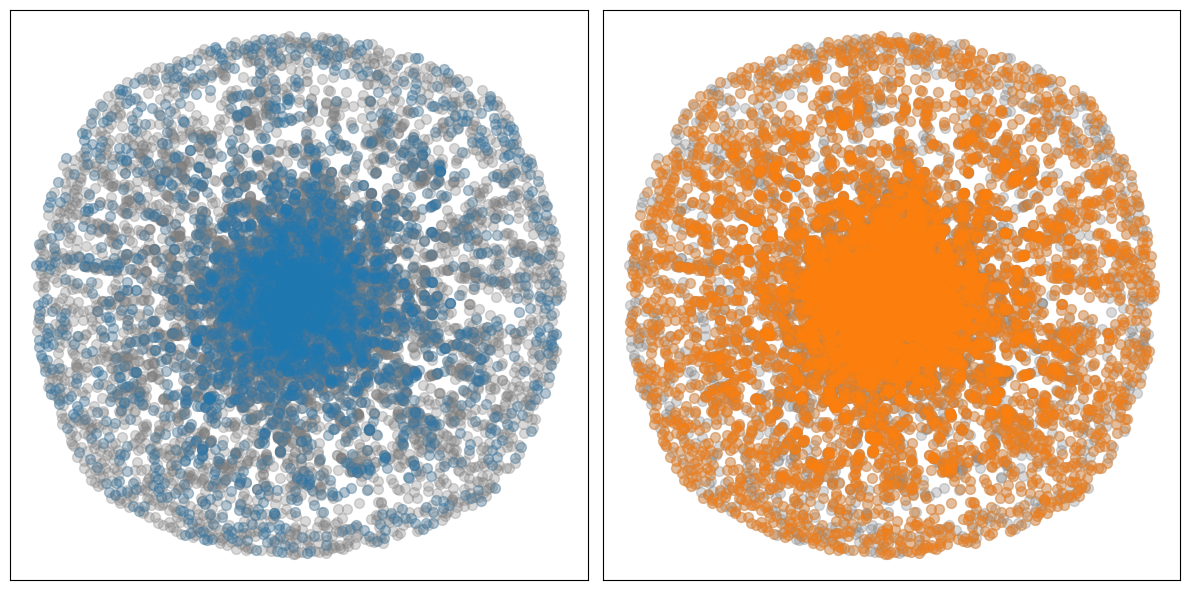

In [7]:
tableau = mpl.colors.TABLEAU_COLORS
fig, axs = plt.subplots(1, 2, figsize=(12,6))

nx.draw_networkx_nodes(cleanG, pos=pos,  
                       node_color=tableau['tab:gray'], alpha=.3, node_size=50, ax=axs[0])
nx.draw_networkx_nodes(cleanG, pos=pos, 
                       nodelist=[n for n in G if econ.get(n)=='Emerging_Market'], 
                       node_color=tableau['tab:blue'], alpha=.2, node_size=50, ax=axs[0])
nx.draw_networkx_nodes(cleanG, pos=pos,  
                       node_color=tableau['tab:gray'], alpha=.3, node_size=50, ax=axs[1])
nx.draw_networkx_nodes(cleanG, pos=pos, 
                       nodelist=[n for n in G if econ.get(n)=='Advanced_Economy'], 
                       node_color=tableau['tab:orange'], alpha=.3, node_size=50, ax=axs[1])
plt.tight_layout()
plt.show()

### Configuration Model

In [8]:
randG = digraph_config_model(G, weight='weight')

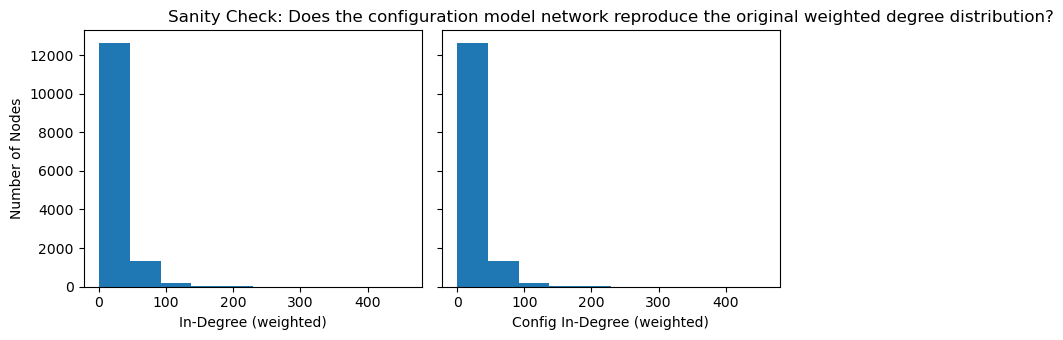

In [9]:
in_wdegrees = dict(G.in_degree(weight='weight'))
rand_in_wdegrees = dict(randG.in_degree(weight='weight'))

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
axs[0].hist(in_wdegrees.values())
axs[1].hist(rand_in_wdegrees.values())
axs[0].set_ylabel("Number of Nodes")
axs[0].set_xlabel("In-Degree (weighted)")
axs[1].set_xlabel("Config In-Degree (weighted)")
plt.title('Sanity Check: Does the configuration model network reproduce the original weighted degree distribution?')
plt.tight_layout()
plt.show()

## Properties

### Degree sequence

In [6]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
weights = nx.get_edge_attributes(G, name="weight")

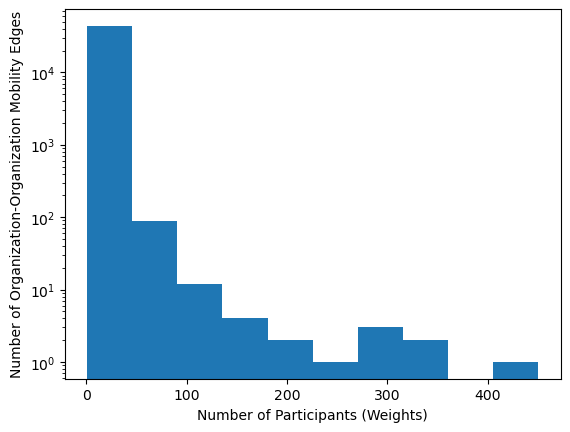

In [16]:
plt.hist(weights.values())
plt.xlabel('Number of Participants (Weights)')
plt.ylabel('Number of Organization-Organization Mobility Edges')
plt.yscale('log')
plt.show()

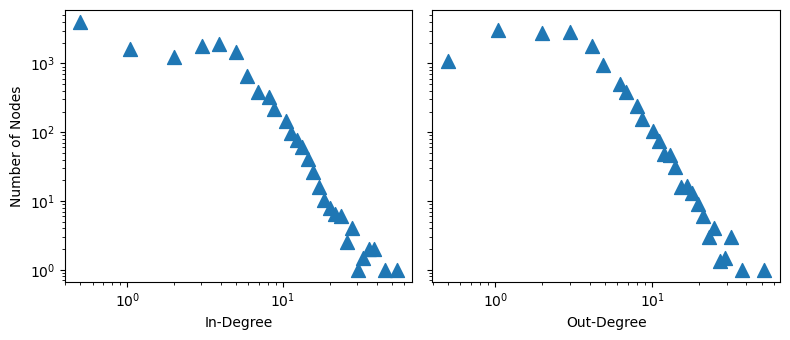

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

bin_counts, bin_centers = bin_degseq(in_degrees.values())
axs[0].scatter(bin_centers, bin_counts, marker='^', s=100)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

bin_counts, bin_centers = bin_degseq(out_degrees.values())
axs[1].scatter(bin_centers, bin_counts, marker='^', s=100)
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('Number of Nodes')
axs[0].set_xlabel('In-Degree')
axs[1].set_xlabel('Out-Degree')

plt.tight_layout()
plt.show()

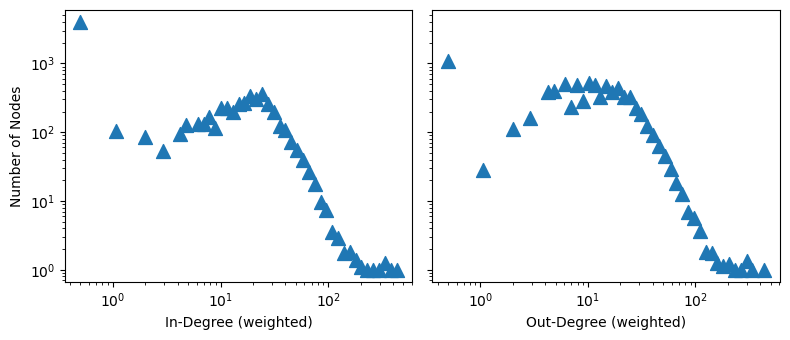

In [8]:
in_degrees = dict(G.in_degree(weight='weight'))
out_degrees = dict(G.out_degree(weight='weight'))

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

bin_counts, bin_centers = bin_degseq(in_degrees.values())
axs[0].scatter(bin_centers, bin_counts, marker='^', s=100)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

bin_counts, bin_centers = bin_degseq(out_degrees.values())
axs[1].scatter(bin_centers, bin_counts, marker='^', s=100)
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('Number of Nodes')
axs[0].set_xlabel('In-Degree (weighted)')
axs[1].set_xlabel('Out-Degree (weighted)')

plt.tight_layout()
plt.show()

### Clustering

In [10]:
cluster_coef = nx.clustering(G, weight="weight")
rand_cluster_coef = nx.clustering(randG, weight='weight')

In [11]:
print(f'Average local clustering coefficient in the observed mobility network is {np.mean(list(cluster_coef.values()))}, and that of one configuration model network is {np.mean(list(rand_cluster_coef.values()))}')

Average local clustering coefficient in the observed mobility network is 0.006777206109256834, and that of one configuration model network is 0.0019791682220378806


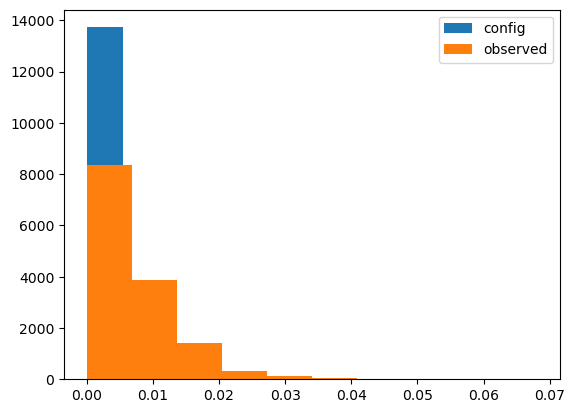

In [12]:
plt.hist(rand_cluster_coef.values(), label='config')
plt.hist(cluster_coef.values(), label='observed')
plt.legend()
plt.show()

### Core-periphery

In [13]:
core = max(nx.weakly_connected_components(G), key=len)
core = G.subgraph(core)

core_mobility_vol = sum(nx.get_edge_attributes(core, 'weight').values())
G_mobility_vol = sum(nx.get_edge_attributes(G, 'weight').values())

directed = 'directed' if core.is_directed() else 'undirected'
weighted = 'weighted' if nx.is_weighted(core) else 'unweighted'

print(f'Y{start}-{end} graph has a giant component with {core.number_of_nodes()} nodes ({len(core)/len(G)*100:.2f}%) and {core.number_of_edges()} {directed}, {weighted} edges ({core.number_of_edges()/G.number_of_edges()*100:.2f}%). ')
print(f'The giant component covers mobility volumns of {core_mobility_vol} participants ({core_mobility_vol/G_mobility_vol*100:.2f}%).')

Y2017-2019 graph has a giant component with 11074 nodes (77.82%) and 38051 directed, weighted edges (86.54%). 
The giant component covers mobility volumns of 248825 participants (81.39%).


### Attribute Assortativity (Homophily)

To assess assortativity with relation to nodal attributes, one can observe the number of same attribute edges and cross-attribute edges.

In [14]:
lang_edgetypes = {}

for s, t, w in G.edges(data="weight"):
    
    langsim = language_similarity(lang[s], lang[t])
    
    if langsim in lang_edgetypes:
        lang_edgetypes[langsim]["pair"] += 1
        lang_edgetypes[langsim]["weighted"] += w
    else:
        lang_edgetypes[langsim]={"pair": 1,
                                 "weighted": w
                                }

<Axes: xlabel='langsim', ylabel='count'>

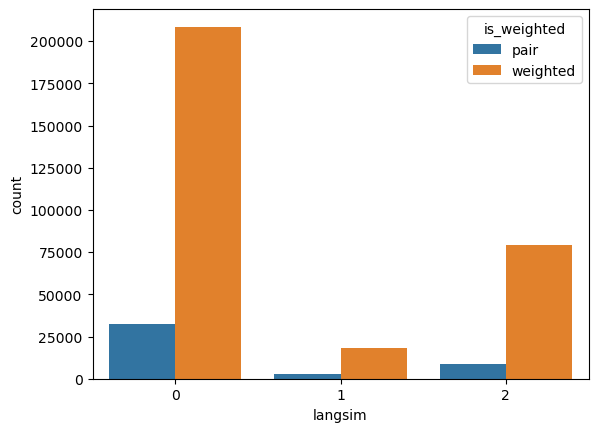

In [15]:
plot_data = pd.DataFrame(lang_edgetypes).T.reset_index(names='langsim')
plot_data = plot_data.melt(id_vars='langsim', value_vars=['pair', 'weighted'], var_name='is_weighted', value_name='count')
sns.barplot(plot_data, x='langsim', y='count', hue='is_weighted')

When there are a small number of node categories, attribute mixing matrix can be useful in identifying assortativity. We use this approach to investigate homophily with respect to geo-cultural factors.

In [16]:
nx.set_node_attributes(G, culture, name='culture')
mapping = {l:ind for ind, l in enumerate(sorted(set(culture.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='culture', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='culture', mapping=mapping)

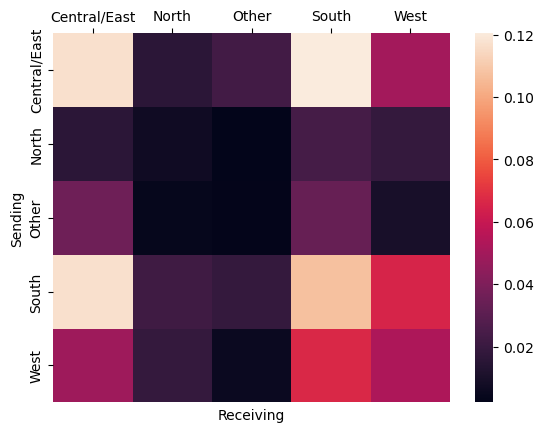

In [17]:
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat)
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.show()

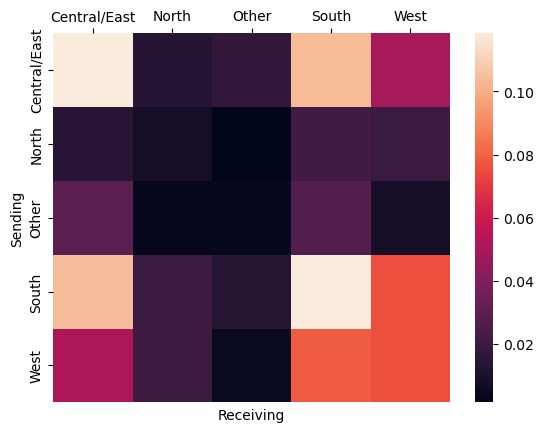

In [18]:
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat)
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.show()

The proprotions of different edge types show more intensive mobility within the Central/Eastern Europe block and moderately strong mobility within Southern Europe and Western Europe. However, due to highly heterogenous degrees, the frequency and scale of mobility each block can have are different, cofounding with homophily. 

Below, we do degree-corrections using the configuration network model to disentangle this cofounder.

In [19]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='culture', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='culture', weight='weight', mapping=mapping)

100%|██████████| 50/50 [03:33<00:00,  4.26s/it]


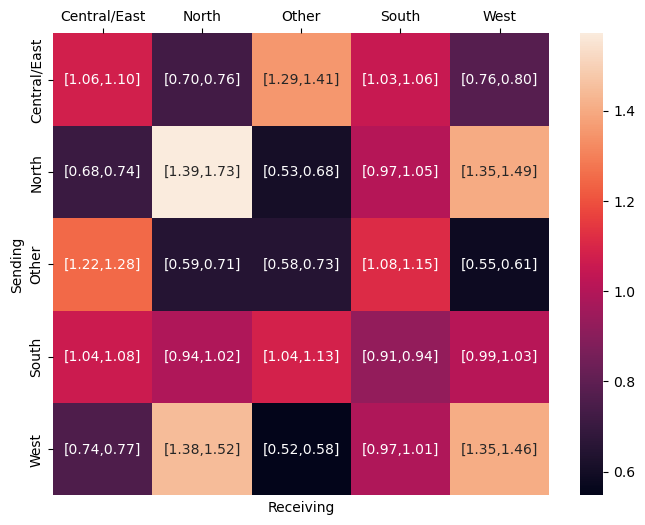

In [20]:
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
plt.figure(figsize=(8,6))
sns.heatmap(df_heat, annot=labels, fmt='')
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

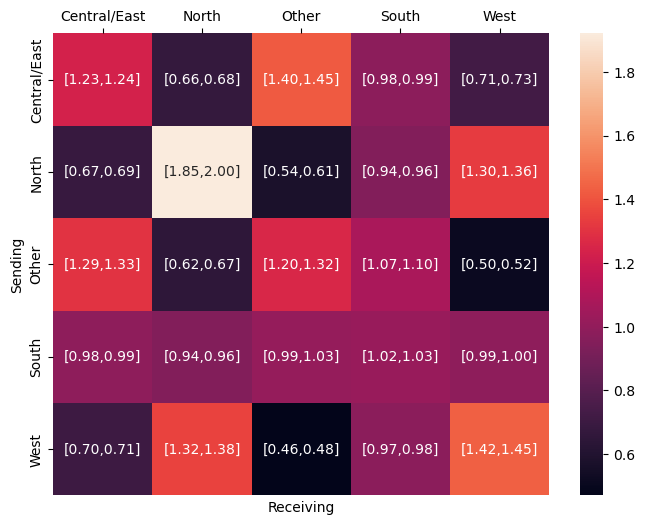

In [22]:
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
plt.figure(figsize=(8,6))
sns.heatmap(df_heat, annot=labels, fmt='')
plt.xlabel('Receiving')
plt.ylabel('Sending')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

Degree correction uncovers some unobserved assortativity among Northern and Western Europeans, along with disassortative patterns in mobility between near Europe countries and Eastern Europe, and that between Northern and Western Europe. 

### Attribute Disassortivity (Core-periphery)

Similarly, mobility patterns between advanced economy and emerging market can be observed with atrribute mixing matrices. Before degree-correction, it seems that there's a core-periphery structure (consistent with the network visualization), particularly with relation to country economic status.

In [23]:
nx.set_node_attributes(G, econ, name='econ')
mapping = {l:ind for ind, l in enumerate(sorted(set(econ.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='econ', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='econ', mapping=mapping)

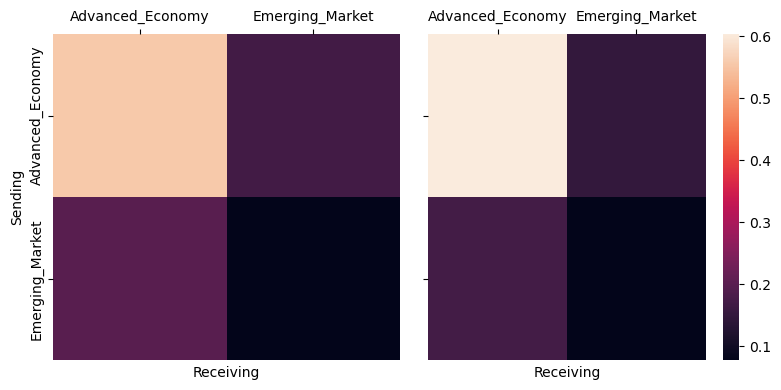

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)
vmin = np.min([mat, wmat])
vmax = np.max([mat, wmat])

# non weighted (% cross-organization mobility)
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')

# weighted (% participants)
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, cbar=True)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
plt.tight_layout()
plt.show()

In [83]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='econ', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='econ', weight='weight', mapping=mapping)

100%|██████████| 50/50 [03:36<00:00,  4.33s/it]


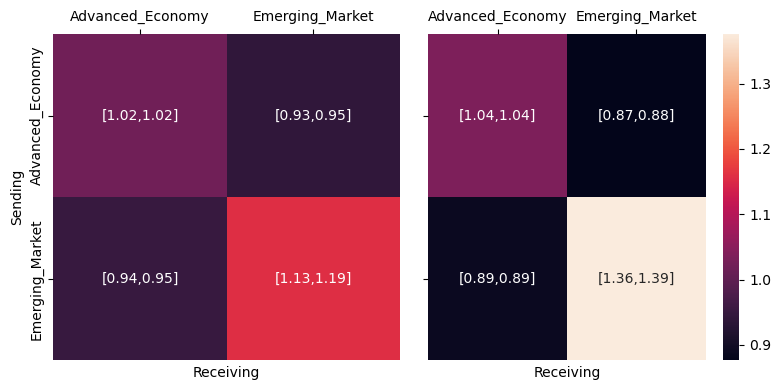

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)
vmin = np.min([relattribute_mixmat, relattribute_wmixmat])
vmax = np.max([relattribute_mixmat, relattribute_wmixmat])

# non weighted (% cross-organization mobility - obs/config) 
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False, annot=labels, fmt='')
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')

# weighted (% participants - obs/config)
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, annot=labels, fmt='')
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
# axs[1].set_ylabel('Sending')

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

After degree-correction, there seems to be correlation between mobility and economic similarity. However, it might not stem from preferences of mobility among organizations from similar economic family alone, as economic and geo-cultural attributes are usually correlated. 